In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.interpolate import interp1d


In [22]:
from scipy.stats import ks_2samp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


In [23]:

# ============================================================================
# CONFIGURATION
# ============================================================================
SIMULATED_DIR = "DM_distribution_new"
REAL_DIR = "DM_distribution_real_data"
ALPHA = 0  # Change this to match your simulated data

# Telescope mapping (simulated : real)
telescope_mapping = {
    'fast': 'fast',
    'parkes': 'parkes',
    'askap_flyeye': 'askap_flyeye',
    'askap_ics': 'askap_ics',
    'dsa-110': 'dsa-110',
    'apertif':'apertif',
    'meerkat_coherent': 'meerkat_CB',
    'meerkat_incoherent': 'meerkat_IB',
}

# ============================================================================
# LOAD SIMULATED DM DISTRIBUTIONS
# ============================================================================
simulated_data = {}
for sim_tel in telescope_mapping.keys():
    filename = f"DM_{sim_tel}_alpha{ALPHA}_scaled.csv"
    filepath = os.path.join(SIMULATED_DIR, filename)
    
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        dm_simulated = df['z'].values * 1000
        simulated_data[sim_tel] = dm_simulated
        print(f"✓ Loaded simulated {sim_tel:20s} - {len(dm_simulated)} bins")

# ============================================================================
# LOAD REAL DM DISTRIBUTIONS
# ============================================================================
real_data = {}
for real_tel in telescope_mapping.values():
    filename = f"{real_tel}.csv"
    filepath = os.path.join(REAL_DIR, filename)
    
    if os.path.exists(filepath):
        try:
            df = pd.read_csv(filepath, engine='python', on_bad_lines='warn')
            
            dm_col = None
            for col in df.columns:
                if 'dm' in col.lower() or 'dispersion' in col.lower():
                    dm_col = col
                    break
            
            if dm_col is not None:
                dm_real = df[dm_col].dropna().values
                real_data[real_tel] = dm_real
                print(f"✓ Loaded real {real_tel:20s} - {len(dm_real)} FRBs")
        except Exception as e:
            print(f"✗ Error loading {real_tel}: {str(e)[:60]}")


✓ Loaded simulated fast                 - 499 bins
✓ Loaded simulated parkes               - 499 bins
✓ Loaded simulated askap_flyeye         - 490 bins
✓ Loaded simulated askap_ics            - 499 bins
✓ Loaded simulated dsa-110              - 499 bins
✓ Loaded simulated apertif              - 499 bins
✓ Loaded simulated meerkat_coherent     - 499 bins
✓ Loaded simulated meerkat_incoherent   - 499 bins
✓ Loaded real fast                 - 10 FRBs
✓ Loaded real parkes               - 30 FRBs
✓ Loaded real askap_flyeye         - 22 FRBs
✓ Loaded real askap_ics            - 43 FRBs
✓ Loaded real dsa-110              - 12 FRBs
✓ Loaded real apertif              - 24 FRBs
✓ Loaded real meerkat_CB           - 18 FRBs
✓ Loaded real meerkat_IB           - 15 FRBs


/tmp/ipykernel_1068730/1673376509.py:44: ParserWarning: Skipping line 22: Expected 18 fields in line 22, saw 19

  df = pd.read_csv(filepath, engine='python', on_bad_lines='warn')
/tmp/ipykernel_1068730/1673376509.py:44: ParserWarning: Skipping line 23: Expected 18 fields in line 23, saw 19

  df = pd.read_csv(filepath, engine='python', on_bad_lines='warn')
/tmp/ipykernel_1068730/1673376509.py:44: ParserWarning: Skipping line 24: Expected 18 fields in line 24, saw 19

  df = pd.read_csv(filepath, engine='python', on_bad_lines='warn')


In [24]:
# ============================================================================
# KS TEST RESULTS (Population-Weighted Simulated vs Real)
# ============================================================================
print("\n" + "="*100)
print("KS TEST RESULTS (Population-Weighted Simulated vs Real)")
print("="*100)

same_tel_ks_weighted = []
for sim_tel, real_tel in telescope_mapping.items():
    if sim_tel not in simulated_data or real_tel not in real_data:
        continue
    
    # Load simulated data with population weights
    filename = f"DM_{sim_tel}_alpha{ALPHA}_scaled.csv"
    filepath = os.path.join(SIMULATED_DIR, filename)
    sim_df = pd.read_csv(filepath)
    
    sim_dm = sim_df['z'].values * 1000
    sim_pop = sim_df['n_total_population_scaled'].values
    
    # Sort by DM and get population-weighted cumulative
    sort_idx = np.argsort(sim_dm)
    sim_dm_sorted = sim_dm[sort_idx]
    sim_pop_sorted = sim_pop[sort_idx]
    sim_cumulative_weighted = np.cumsum(sim_pop_sorted) / np.cumsum(sim_pop_sorted)[-1]
    
    # Real data (unweighted)
    real_dm = real_data[real_tel]
    real_cumulative = np.arange(1, len(real_dm) + 1) / len(real_dm)
    
    # Perform KS test
    statistic, p_value = ks_2samp(sim_dm_sorted, real_dm)
    
    same_tel_ks_weighted.append({
        'Telescope': sim_tel.upper(),
        'Simulated_N': len(sim_dm),
        'Real_N': len(real_dm),
        'KS_Statistic': statistic,
        'P_Value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })
    
    print(f"{sim_tel.upper():20s} | KS: {statistic:.4f} | p-value: {p_value:.6f} | Sig: {'Yes' if p_value < 0.05 else 'No'}")

print("="*100)


KS TEST RESULTS (Population-Weighted Simulated vs Real)
FAST                 | KS: 0.4972 | p-value: 0.009309 | Sig: Yes
PARKES               | KS: 0.5754 | p-value: 0.000000 | Sig: Yes
ASKAP_FLYEYE         | KS: 0.8096 | p-value: 0.000000 | Sig: Yes
ASKAP_ICS            | KS: 0.7839 | p-value: 0.000000 | Sig: Yes
DSA-110              | KS: 0.8597 | p-value: 0.000000 | Sig: Yes
APERTIF              | KS: 0.6678 | p-value: 0.000000 | Sig: Yes
MEERKAT_COHERENT     | KS: 0.5823 | p-value: 0.000004 | Sig: Yes
MEERKAT_INCOHERENT   | KS: 0.6012 | p-value: 0.000015 | Sig: Yes


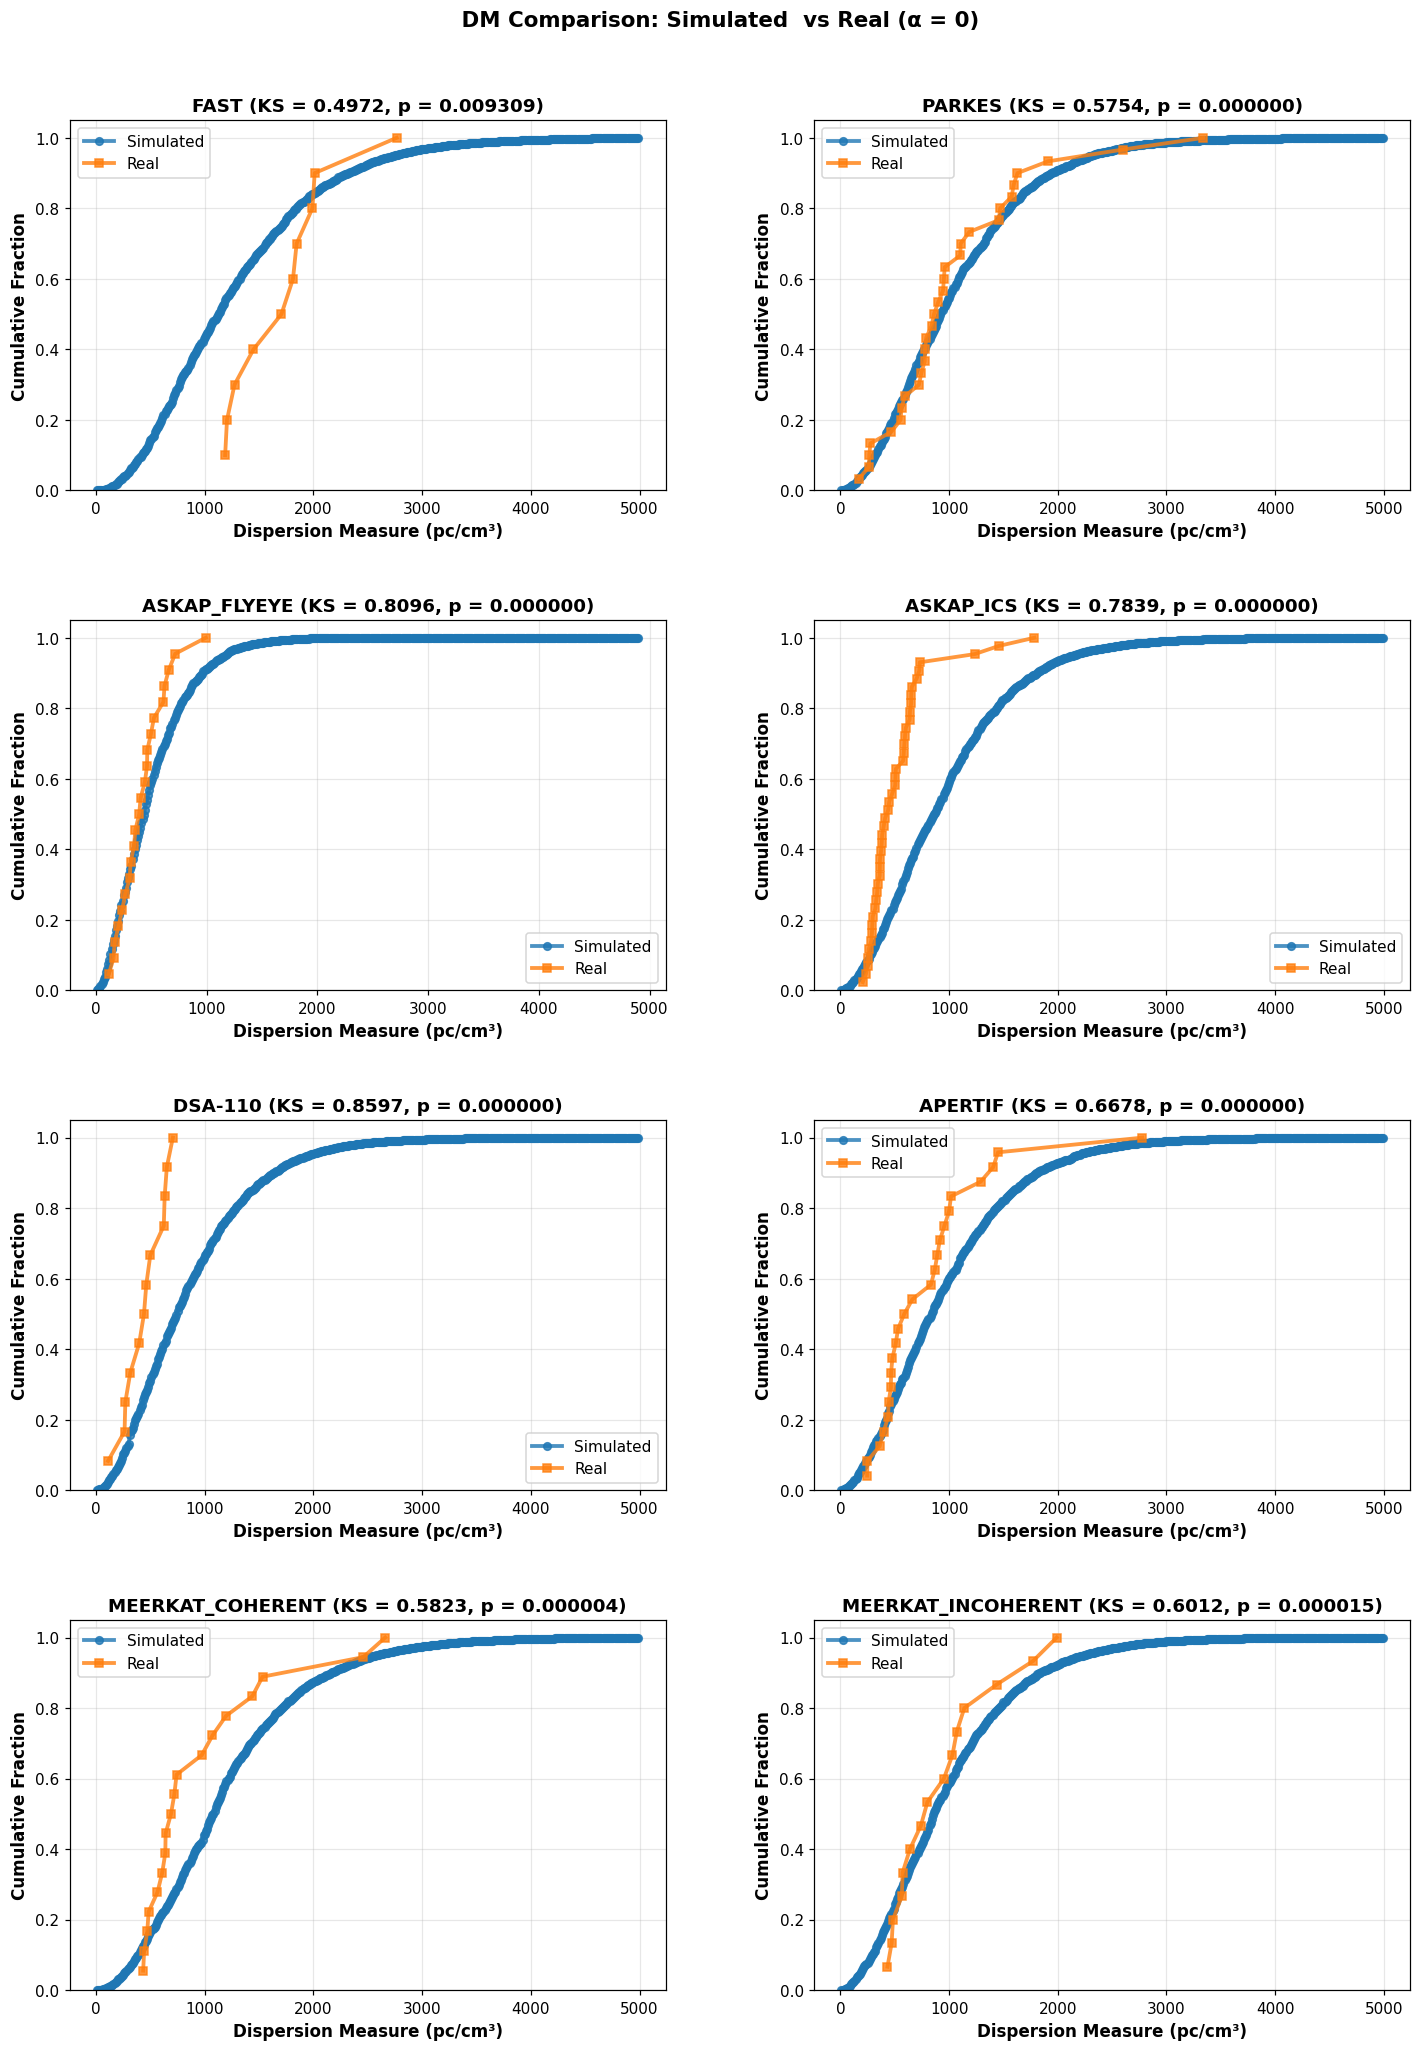

In [25]:
# ============================================================================
# VISUALIZATION: WEIGHTED DM COMPARISON (Population-Weighted Simulated)
# ============================================================================
if same_tel_ks_weighted:
    df_same_weighted = pd.DataFrame(same_tel_ks_weighted)
    n_matching = len(same_tel_ks_weighted)
    n_cols = 2
    n_rows = (n_matching + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows), dpi=110)
    if n_rows == 1:
        axes = [axes]
    axes = axes.flatten()
    
    for idx, (sim_tel, real_tel) in enumerate(telescope_mapping.items()):
        if sim_tel not in simulated_data or real_tel not in real_data:
            continue
        
        ax = axes[idx]
        
        # Load simulated with population weights
        filename = f"DM_{sim_tel}_alpha{ALPHA}_scaled.csv"
        filepath = os.path.join(SIMULATED_DIR, filename)
        sim_df = pd.read_csv(filepath)
        
        sim_dm = sim_df['z'].values * 1000
        sim_pop = sim_df['n_total_population_scaled'].values
        
        # Sort and weight
        sort_idx = np.argsort(sim_dm)
        sim_dm_sorted = sim_dm[sort_idx]
        sim_pop_sorted = sim_pop[sort_idx]
        sim_cumulative_weighted = np.cumsum(sim_pop_sorted) / np.cumsum(sim_pop_sorted)[-1]
        
        # Real data (unweighted)
        real_dm = real_data[real_tel]
        real_cumulative = np.arange(1, len(real_dm) + 1) / len(real_dm)
        
        # Plot on linear scale
        ax.plot(sim_dm_sorted, sim_cumulative_weighted, 'o-', linewidth=2.5, 
                   markersize=5, label='Simulated', color='#1f77b4', alpha=0.8)
        ax.plot(np.sort(real_dm), real_cumulative, 's-', linewidth=2.5, 
                   markersize=5, label='Real', color='#ff7f0e', alpha=0.8)
        
        # Get KS statistic and p-value
        ks_val = df_same_weighted.loc[df_same_weighted['Telescope'] == sim_tel.upper(), 'KS_Statistic'].values[0]
        p_val = df_same_weighted.loc[df_same_weighted['Telescope'] == sim_tel.upper(), 'P_Value'].values[0]
        
        ax.set_xlabel('Dispersion Measure (pc/cm³)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Cumulative Fraction', fontsize=11, fontweight='bold')
        ax.set_title(f'{sim_tel.upper()} (KS = {ks_val:.4f}, p = {p_val:.6f})', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, which='both')
        ax.legend(loc='best', fontsize=10)
        ax.set_ylim([0, 1.05])
    
    # Hide extra subplots
    for idx in range(n_matching, len(axes)):
        axes[idx].set_visible(False)
    
    fig.suptitle(f' DM Comparison: Simulated  vs Real (α = {ALPHA})', 
                fontsize=14, fontweight='bold')
    
    # Use subplots_adjust instead of tight_layout (faster)
    fig.subplots_adjust(left=0.08, right=0.95, top=0.93, bottom=0.08, hspace=0.35, wspace=0.25)
    
    # plt.savefig(f"dm_comparison_weighted_alpha{ALPHA}.png", dpi=150, bbox_inches='tight')
    plt.show()